# Raw FITS Files

In [1]:
import numpy as np
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy
import scipy.io as sio
import csv
from scipy.io import readsav
import pandas as pd
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Label, LabelSet,BoxAnnotation
from astropy.io import fits
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
output_notebook()

NORMALIZATION_INDEX = 800

Loading BokehJS ...

# Headers

In [2]:
image_file = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/encrenaz_fits_files/TX22A0624.2038.01.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file) as hdu_list:
    object_info= hdu_list.info() #display the extensions of the fits file
    primary_header = hdu_list[0].header #store primary header
    extracted_header= hdu_list[1].header #store extracted header
    sky_header= hdu_list[2].header #store sky header
    scan_noise_header= hdu_list[3].header #store noise header

    primary=hdu_list[0]
    
    wavenumber = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber.tolist() #make it into a list

    image_data=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file


Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/encrenaz_fits_files/TX22A0624.2038.01.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     144   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


In [3]:
print(primary_header)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    3                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  NAXIS3  =                   47                                                  EXTEND  =                    T                                                  COMMENT   The primary data unit contains a spectral-spatial-spatial             COMMENT    data cube                                                            COMMENT   The primary HDU is followed by a table extension                      COMMENT   (EXTNAME = EXTRACTED)                                                 COMMENT   giving the observed vacuum wavenumbers,                               COMMENT   flux through the slit, estimat

In [4]:
print(extracted_header)

XTENSION= 'TABLE   '                                                            BITPIX  =                    8                                                  NAXIS   =                    2                                                  NAXIS1  =                   80                                                  NAXIS2  =                 1792                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  TFIELDS =                    5                                                  EXTNAME = 'EXTRACTED'                                                           TTYPE1  = 'WAVENUMBER'  / observed vacuum wavenumber                            TBCOL1  =                    1                                                  TFORM1  = 'F12.4'                                                               TUNIT1  = 'cm^-1   '                    

In [5]:
print(sky_header)

XTENSION= 'IMAGE   '                                                            BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  CTYPE1  = 'spectral pixel'                                                      EXTNAME = 'SKY'  / sky frame which was subtracted from scan frames              BUNIT   = 'erg / s cm2 cm-1 sr'                                                 CTYPE2  = 'pixel along slit'                                                    END                                                                                                                     

In [6]:
print(scan_noise_header)

XTENSION= 'IMAGE   '                                                            BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  CTYPE1  = 'spectral pixel'                                                      EXTNAME = 'SCAN-NOISE'  / calculated noise in each scan frame                   BUNIT   = 'erg / s cm2 cm-1 sr'                                                 CTYPE2  = 'pixel along slit'                                                    END                                                                                                                     

# Data Load-In

## Line-by-Line

In [8]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/line_by_line/H2O_line_by_line.txt',header=None) 
wn=df.loc[:,1]
abund=df.loc[:,2]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

#Region 1:
mol_lambda1=[]
abund_lambda1=[]
for a in range(0,len(split_array),1):
    #if split_array[a,0] > 1114.7114576040406 and split_array[a,0] < 1123.696475590839:
    if split_array[a,0] > 1342 and split_array[a,0] < 1348:
        if split_array[a,1] > 1e-25: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(mol_lambda1))
range1_array=np.stack((mol_lambda1, abund_lambda1),axis=-1) #make locations and strengths one array
line_locations_region_1 = np.array(mol_lambda1) #make it match previous naming structure

0


# Geographical Information

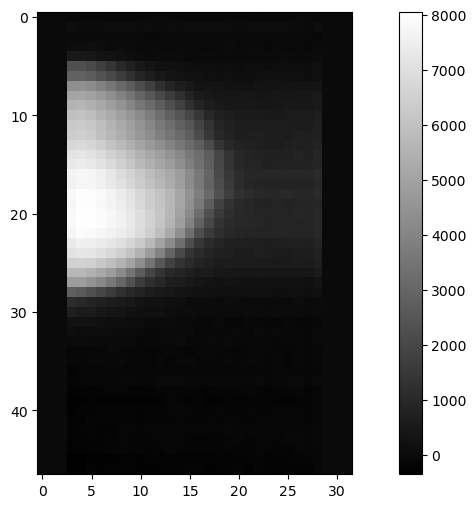

In [9]:
total_image = np.sum(image_data,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

# FITS Spectra

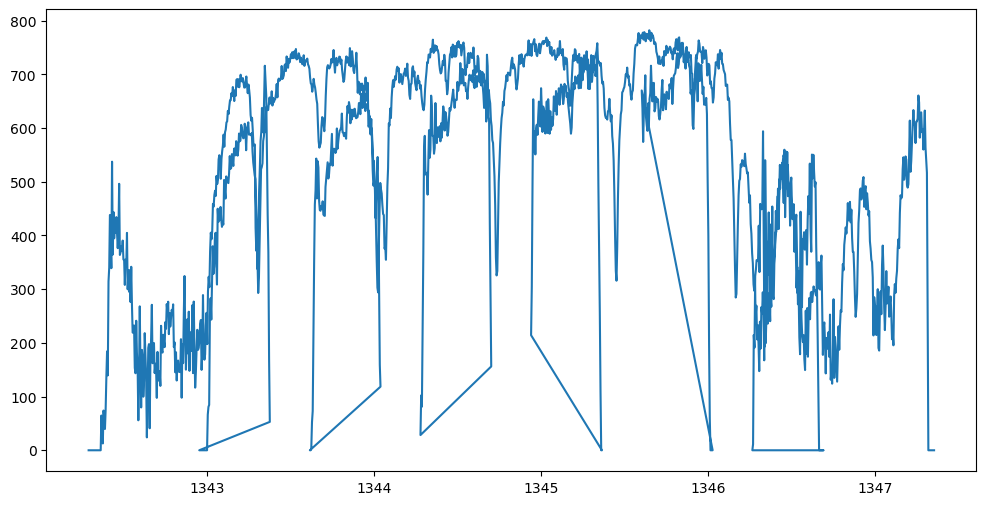

In [10]:
spectrum = np.sum(np.sum(image_data[11:31,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792 #summed over subset of x and y on disk of Venus to get spectrum

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wavenumber,spectrum)

plt.show()

# PSG Spectra

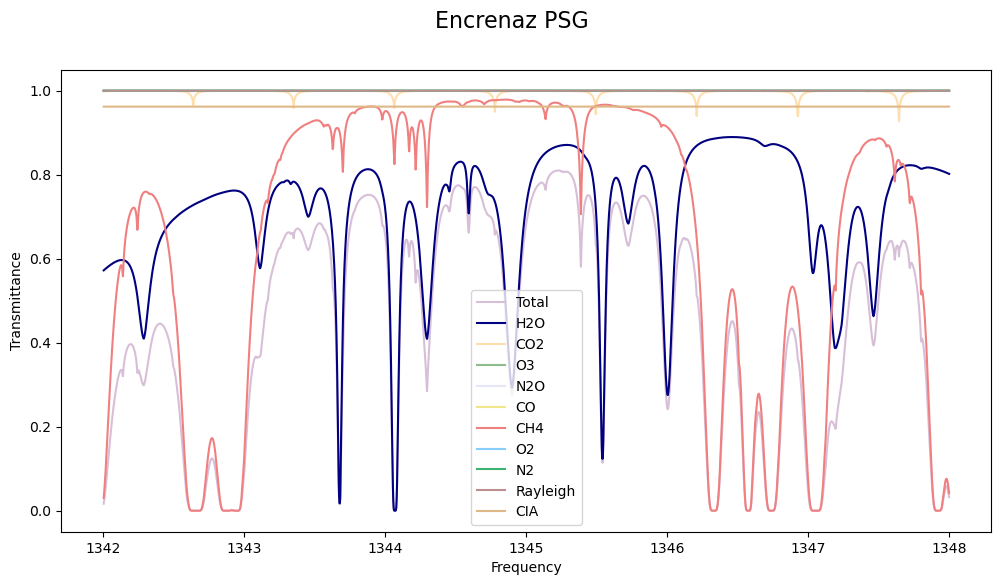

In [13]:
encrenaz_wavenumber = []
encrenaz_total_spectrum = []
encrenaz_H2O_spectrum = []
encrenaz_CO2_spectrum = []
encrenaz_O3_spectrum = []
encrenaz_N2O_spectrum = []
encrenaz_CO_spectrum = []
encrenaz_CH4_spectrum = []
encrenaz_O2_spectrum = []
encrenaz_N2_spectrum = []
encrenaz_HNO3_spectrum = []
encrenaz_Rayleigh_spectrum = []
encrenaz_CIA_spectrum = []


with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - encrenaz_PSG.csv') as encrenaz_psg_file:  
    plots = csv.reader(encrenaz_psg_file, delimiter = ',') 
      
    for row in plots: 
        encrenaz_wavenumber.append(float(row[0]))
        encrenaz_total_spectrum.append(float(row[1]))
        encrenaz_H2O_spectrum.append(float(row[2]))
        encrenaz_CO2_spectrum.append(float(row[3]))
        encrenaz_O3_spectrum.append(float(row[4]))
        encrenaz_N2O_spectrum.append(float(row[5]))
        encrenaz_CO_spectrum.append(float(row[6]))
        encrenaz_CH4_spectrum.append(float(row[7]))
        encrenaz_O2_spectrum.append(float(row[8]))
        encrenaz_N2_spectrum.append(float(row[9]))
        encrenaz_Rayleigh_spectrum.append(float(row[10]))
        encrenaz_CIA_spectrum.append(float(row[11]))
        
fig, ax = plt.subplots(figsize=(12, 6))
plt.xlabel('Frequency')
plt.ylabel('Transmittance')
fig.suptitle('Encrenaz PSG', fontsize=16)


ax.plot(encrenaz_wavenumber,encrenaz_total_spectrum, label = 'Total', color='thistle')
ax.plot(encrenaz_wavenumber,encrenaz_H2O_spectrum, label = 'H2O', color='navy')
ax.plot(encrenaz_wavenumber,encrenaz_CO2_spectrum, label = 'CO2', color='navajowhite')
ax.plot(encrenaz_wavenumber,encrenaz_O3_spectrum, label = 'O3', color='darkseagreen')
ax.plot(encrenaz_wavenumber,encrenaz_N2O_spectrum, label = 'N2O', color='lavender')
ax.plot(encrenaz_wavenumber,encrenaz_CO_spectrum, label = 'CO',  color='khaki')
ax.plot(encrenaz_wavenumber,encrenaz_CH4_spectrum, label = 'CH4', color='lightcoral')
ax.plot(encrenaz_wavenumber,encrenaz_O2_spectrum, label = 'O2', color='lightskyblue')
ax.plot(encrenaz_wavenumber,encrenaz_N2_spectrum, label = 'N2', color='mediumseagreen')
ax.plot(encrenaz_wavenumber,encrenaz_Rayleigh_spectrum, label = 'Rayleigh', color='rosybrown')
ax.plot(encrenaz_wavenumber,encrenaz_CIA_spectrum, label = 'CIA', color='burlywood')

plt.legend()

plt.show()        

In [15]:
#Telluric correction starts here

# Define the exponents
ex1 = 0.6
ex2 = 0.8
ex3 = 0.9
k = 2.0
sh = 0.3
tr1 = np.array(encrenaz_CH4_spectrum) #Turn molecular transmission spectra into arrays
tr2 = np.array(encrenaz_H2O_spectrum)
tr3 = np.array(encrenaz_CO2_spectrum)

def gauss_smooth(data, sigma):
    return gaussian_filter1d(data, sigma) #Define Gaussian smoothing function

def interpolate_model_with_shift(model_wavenumber, model_spectrum, target_wavenumber, shift):
    shifted_wavenumber = np.array(model_wavenumber) + shift #shift PSG wavenumbers by empirical value
    interpolation_function = interp1d(shifted_wavenumber, model_spectrum, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interpolation_function(target_wavenumber) #define interpolation function

# Combine the transmission models with exponents
combined_model = tr1**ex1 * tr2**ex2 * tr3**ex3 #create transmission model using PSG molecular spectra and exponents

# Apply Gaussian smoothing
smoothed_model = gauss_smooth(combined_model, k) #first perform Gaussian smoothing
 
# Interpolate the transmission models with shift
tell = interpolate_model_with_shift(encrenaz_wavenumber, smoothed_model, wavenumber, sh) #then perform interpolation
normalized_spectrum = spectrum / np.median(spectrum) #normalize spectrum for convenience 



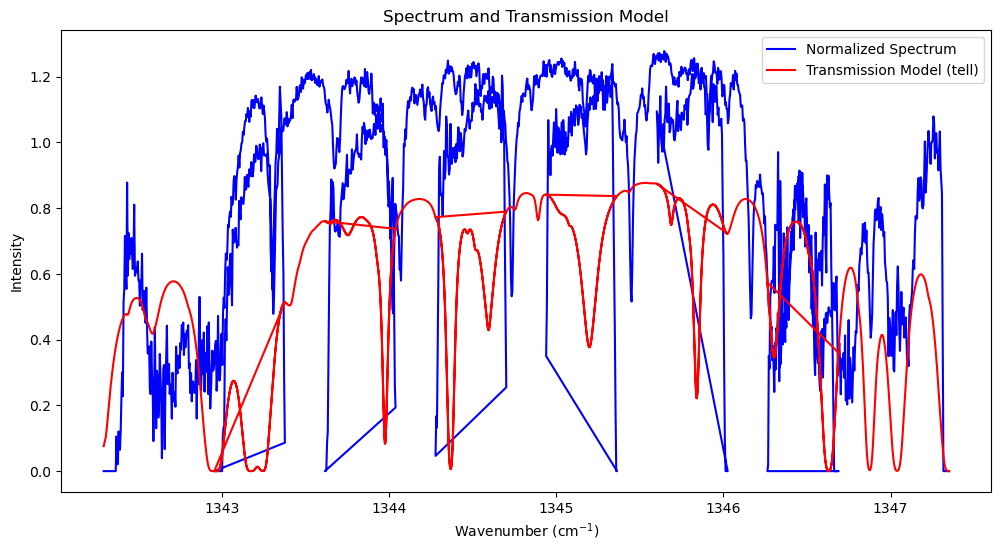

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavenumber, normalized_spectrum, label='Normalized Spectrum', color='blue') #plot normalized spectrum
ax.plot(wavenumber, tell, label='Transmission Model (tell)', color='red') #overplot transmission model
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Intensity')
ax.set_title('Spectrum and Transmission Model')
ax.legend()
plt.show()

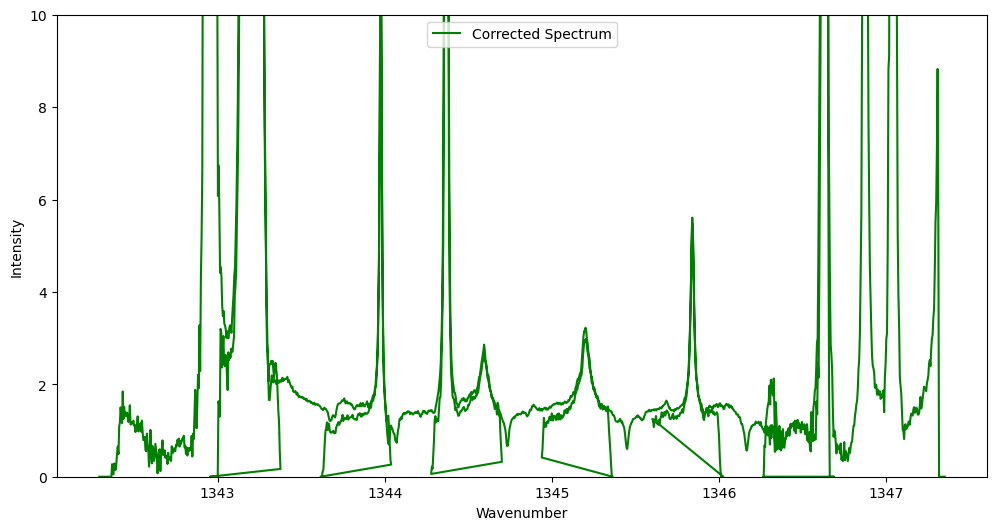

In [21]:
corrected_spectrum = normalized_spectrum / tell #divide spectrum by transmission model (telluric correction)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wavenumber, corrected_spectrum, label='Corrected Spectrum', color='green') #plot telluric-corrected spectru,
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.ylim((0,10))
plt.legend()
plt.show()

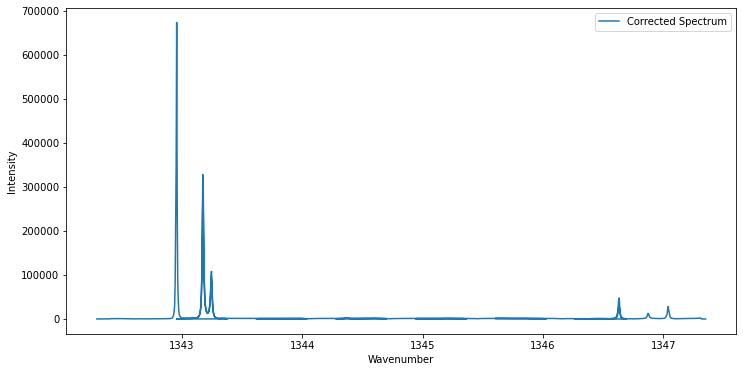

In [34]:
#this was my previous attempt (feel free to ignore)


# Define the parameters
ex1 = 0.6
ex3 = 0.8
ex2 = 0.9
ex4 = 0.9
k = 2.0
sh = 0.3

# Define interpolation function with shift
def interpolate_model_with_shift(model_wavenumber, model_spectrum, target_wavenumber, shift):
    shifted_wavenumber = np.array(model_wavenumber) + shift  # Convert to NumPy array and add shift
    interpolation_function = interp1d(shifted_wavenumber, model_spectrum, kind='linear', bounds_error=False, fill_value="extrapolate")
    return interpolation_function(target_wavenumber)

# Interpolate the transmission models with shift
tr1_interpolated_shifted = interpolate_model_with_shift(encrenaz_wavenumber, encrenaz_CH4_spectrum, wavenumber, sh)
tr3_interpolated_shifted = interpolate_model_with_shift(encrenaz_wavenumber, encrenaz_H2O_spectrum, wavenumber, sh)
tr2_interpolated_shifted = interpolate_model_with_shift(encrenaz_wavenumber, encrenaz_CO2_spectrum, wavenumber, sh)
tr4_interpolated_shifted = interpolate_model_with_shift(encrenaz_wavenumber, encrenaz_HNO3_spectrum, wavenumber, sh)


# Apply exponents
tr1_exponentiated = tr1_interpolated_shifted ** ex1
tr2_exponentiated = tr2_interpolated_shifted ** ex2
tr3_exponentiated = tr3_interpolated_shifted ** ex3
tr4_exponentiated = tr4_interpolated_shifted ** ex4

# Combine transmission models
combined_transmission = tr1_exponentiated * tr2_exponentiated * tr3_exponentiated * tr4_exponentiated

# Apply Gaussian smoothing
smoothed_transmission = gaussian_filter1d(combined_transmission, sigma=k)

# Apply the transmission model to the spectrum
corrected_spectrum = spectrum / smoothed_transmission

# Plot the results
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(wavenumber, corrected_spectrum, label='Corrected Spectrum')
plt.xlabel('Wavenumber')
plt.ylabel('Intensity')
plt.legend()
plt.show()


In [15]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Encrenaz PSG",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber, encrenaz_total_spectrum, legend_label='Earth', color='thistle')
q.line(encrenaz_wavenumber, encrenaz_H2O_spectrum,legend_label='H2O', color='navy')
q.line(encrenaz_wavenumber, encrenaz_CO2_spectrum,legend_label='CO2', color='navajowhite')
q.line(encrenaz_wavenumber, encrenaz_O3_spectrum,legend_label='O3', color='darkseagreen')
q.line(encrenaz_wavenumber, encrenaz_N2O_spectrum,legend_label='N2O', color='lavender')
q.line(encrenaz_wavenumber, encrenaz_CO_spectrum,legend_label='CO', color='khaki')
q.line(encrenaz_wavenumber, encrenaz_CH4_spectrum,legend_label='CH4', color='lightcoral')
q.line(encrenaz_wavenumber, encrenaz_O2_spectrum,legend_label='O2', color='lightskyblue')
q.line(encrenaz_wavenumber, encrenaz_N2_spectrum,legend_label='N2', color='mediumseagreen')
q.line(encrenaz_wavenumber, encrenaz_Rayleigh_spectrum,legend_label='Rayleigh', color='rosybrown')
q.line(encrenaz_wavenumber, encrenaz_CIA_spectrum,legend_label='CIA', color='burlywood')


q.legend.location = "bottom_right"

show(q)